In [1]:
# Cell 1 - Imports and Logging
import sys, logging, warnings
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

logging.basicConfig(level=logging.INFO,
    format="%(asctime)s | %(name)s | %(message)s")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.analytics.db_connector import get_connection, populate_articles, query_articles
from src.analytics.data_combiner import merge_mysql_mongodb, demonstrate_join_types

print("Imports successful")

Imports successful


In [2]:
# Cell 2 - Load cleaned articles CSV
cleaned_df = pd.read_csv("../data/processed/cleaned/articles_clean.csv")
print(f"Loaded {len(cleaned_df)} cleaned rows")
print(cleaned_df.dtypes)

# Parse publish_year from publishedAt if not already present
if "publish_year" not in cleaned_df.columns and "publishedAt" in cleaned_df.columns:
    cleaned_df["publish_year"] = pd.to_datetime(
        cleaned_df["publishedAt"], errors="coerce", utc=True
    ).dt.year.fillna(0).astype(int)

# Add content_length as a numeric feature
if "content" in cleaned_df.columns:
    cleaned_df["content_length"] = cleaned_df["content"].str.len().fillna(0).astype(int)

print(f"\ncontent_length stats:")
print(cleaned_df["content_length"].describe())

Loaded 297 cleaned rows
source_name        object
title              object
author             object
description        object
publishedAt        object
content            object
text              float64
ID                float64
Title             float64
Source            float64
Author            float64
Published Date    float64
Word Count        float64
Category          float64
Nutrition         float64
Pharmacology      float64
Mental Health     float64
Total             float64
raw_text          float64
processed_text    float64
published_date    float64
image_url         float64
published_year      int64
dtype: object

content_length stats:
count    297.000000
mean     212.838384
std       10.065703
min      110.000000
25%      213.000000
50%      214.000000
75%      214.000000
max      272.000000
Name: content_length, dtype: float64


In [9]:
# Cell 3 - Connect to MySQL, create table if needed, and populate health_articles
conn = get_connection(host="localhost", user="root", password="root", database="health_pipeline")

cursor = conn.cursor()
cursor.execute("""
    CREATE TABLE IF NOT EXISTS health_articles (
        id          INT AUTO_INCREMENT PRIMARY KEY,
        source_id   VARCHAR(255),
        title       VARCHAR(500) NOT NULL,
        source_name VARCHAR(255),
        author      VARCHAR(255),
        publishedAt DATETIME,
        description TEXT,
        content     MEDIUMTEXT,
        url         VARCHAR(2083),
        publish_year SMALLINT,
        UNIQUE KEY  idx_url (url(500)),
        INDEX idx_source_name (source_name),
        INDEX idx_publish_year (publish_year)
    ) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
""")
conn.commit()
print("Table health_articles ready")

cursor.execute("DELETE FROM health_articles")
conn.commit()
cursor.execute("SELECT COUNT(*) FROM health_articles")
print("Rows after delete:", cursor.fetchone()[0])
cursor.close()

# Insert from cleaned CSV
inserted, skipped = populate_articles(conn, cleaned_df)
print(f"Inserted: {inserted} | Skipped: {skipped}")

2026-05-06 12:14:38,812 | src.analytics.db_connector | Connected to MySQL database: health_pipeline
2026-05-06 12:14:38,895 | src.analytics.db_connector | Inserted 297 rows, skipped 0 rows


Table health_articles ready
Rows after delete: 0
Inserted: 297 | Skipped: 0


In [10]:
# Cell 4 - Query articles from MySQL
mysql_df = query_articles(conn, sql="""
    SELECT source_id, title, source_name, author, publishedAt, url, publish_year
    FROM health_articles
    WHERE title IS NOT NULL AND title != ''
""")
print(f"MySQL rows: {len(mysql_df)}")
print(mysql_df[["title", "source_name", "author", "publish_year"]].head(10))
print(mysql_df["publish_year"].isna().sum())

2026-05-06 12:14:44,506 | src.analytics.db_connector | Queried 297 rows from MySQL


MySQL rows: 297
                                               title              source_name  \
0  Scientists discover diet that tricks the body ...            Science Daily   
1  Nature’s powerhouses: The top 8 healthiest ber...          Naturalnews.com   
2  6 Things You Should Do After 5 P.M. to Support...           Eatingwell.com   
3  "Thema hat sich nicht erledigt": Günther will ...                  N-tv.de   
4                      Can you reverse dog diabetes?    Lifesciencesworld.com   
5  Why there is a distressing rise in kidney disease      Scientific American   
6  Olivenöl-Zitronen-Shot: Neues Wundermittel für...  CHIP Online Deutschland   
7  Dormir más no siempre ayuda: el dato clave sob...              Gizmodo.com   
8       Was eine Zuckersteuer wirklich bringen würde            tagesschau.de   
9              8 Hidden Health Benefits of Green Tea                     CNET   

                                  author  publish_year  
0                                  

In [12]:
# Cell 5 - Select content columns (simulating MongoDB source)
mongo_cols = ["url", "title", "source_name", "author", "publishedAt", "content", "description"]
mongo_cols_available = [c for c in mongo_cols if c in cleaned_df.columns]
mongo_df = cleaned_df[mongo_cols_available].copy()

# Pick best available merge key common to both DataFrames
for candidate in ["url", "title", "source_id"]:
    if candidate in mysql_df.columns and candidate in mongo_df.columns:
        merge_key = candidate
        break
else:
    raise ValueError(
        f"No common merge key found.\n"
        f"  mysql_df cols: {list(mysql_df.columns)}\n"
        f"  mongo_df cols: {list(mongo_df.columns)}"
    )

print(f"Merging on: '{merge_key}'")
combined_df = merge_mysql_mongodb(mysql_df, mongo_df, on=merge_key, how="inner")
print(f"Combined DataFrame shape: {combined_df.shape}")
print(combined_df.columns.tolist())
combined_df.head(3)

2026-05-06 12:16:33,636 | src.analytics.data_combiner | Merging MySQL (297 rows) and MongoDB (297 rows) on "title" with how="inner"
2026-05-06 12:16:33,642 | src.analytics.data_combiner | Merged result: 301 rows, 12 columns


Merging on: 'title'
Combined DataFrame shape: (301, 12)
['source_id', 'title', 'source_name_mysql', 'author_mysql', 'publishedAt_mysql', 'url', 'publish_year', 'source_name_mongo', 'author_mongo', 'publishedAt_mongo', 'content', 'description']


,source_id,title,source_name_mysql,author_mysql,publishedAt_mysql,url,publish_year,source_name_mongo,author_mongo,publishedAt_mongo,content,description
0,None,Scientists discover diet that tricks the body ...,Science Daily,nan,2026-02-27 18:05:43,None,2026,Science Daily,NaN,2026-02-27 18:05:43+00:00,"Shivering in the cold is uncomfortable, but it...",Researchers found that cutting two amino acids...
1,None,Nature’s powerhouses: The top 8 healthiest ber...,Naturalnews.com,Belle Carter,2026-03-12 06:00:00,None,2026,Naturalnews.com,Belle Carter,2026-03-12 06:00:00+00:00,"<ul><li>Berries are rich in vitamin C, fiber a...","Berries are rich in vitamin C, fiber and polyp..."
2,None,6 Things You Should Do After 5 P.M. to Support...,Eatingwell.com,Cheyenne Buckingham,2026-03-13 21:30:00,None,2026,Eatingwell.com,Cheyenne Buckingham,2026-03-13 21:30:00+00:00,"Reviewed by Dietitian Sarah Pflugradt, Ph.D., ...",Aging is a privilege—support your health in la...


Join type comparison (rows returned):
  inner  join ->   301 rows
  left   join ->   301 rows
  right  join ->   301 rows
  outer  join ->   301 rows


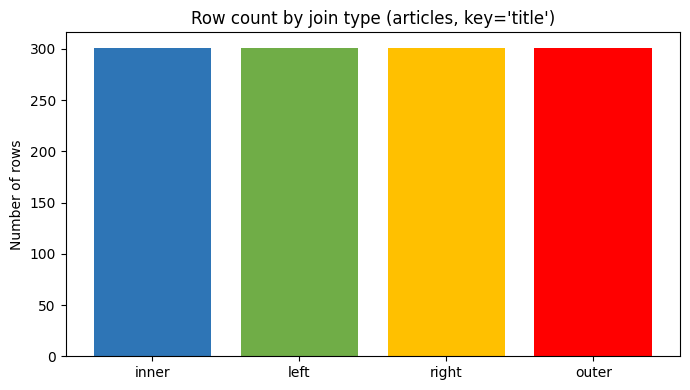

In [13]:
# Cell 6 - Join type comparison
print("Join type comparison (rows returned):")
join_counts = demonstrate_join_types(mysql_df, mongo_df, on=merge_key)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(join_counts.keys(), join_counts.values(),
       color=["#2E75B6", "#70AD47", "#FFC000", "#FF0000"])
ax.set_title(f"Row count by join type (articles, key='{merge_key}')")
ax.set_ylabel("Number of rows")
plt.tight_layout()
plt.savefig("../data/processed/analytics/join_comparison.png", dpi=120)
plt.show()

In [15]:
# Cell 7 - Pivot builder setup
from src.analytics.pivot_builder import wide_to_long, build_pivot_table, build_crosstab, articles_per_source_year

df = combined_df.copy()

# Resolve suffixed duplicate columns produced by the merge
for col in ["title", "source_name", "author", "publishedAt"]:
    mysql_col = f"{col}_mysql"
    mongo_col = f"{col}_mongo"
    if mysql_col in df.columns:
        df[col] = df[mysql_col].fillna(df[mongo_col]) if mongo_col in df.columns else df[mysql_col]

# Ensure content_length is present
if "content" in df.columns:
    df["content_length"] = df["content"].str.len().fillna(0).astype(int)

print("Columns:", df.columns.tolist())
print("\nTop sources in dataset:")
print(df["source_name"].value_counts().head(10))

Columns: ['source_id', 'title', 'source_name_mysql', 'author_mysql', 'publishedAt_mysql', 'url', 'publish_year', 'source_name_mongo', 'author_mongo', 'publishedAt_mongo', 'content', 'description', 'source_name', 'author', 'publishedAt', 'content_length']

Top sources in dataset:
source_name
Naturalnews.com        26
Scientific American    20
Nature.com             19
Science Daily          18
mindbodygreen.com      18
Die Zeit               12
Yahoo Entertainment    11
Okdiario.com            9
Alltoc.com              7
Olhardigital.com.br     7
Name: count, dtype: int64


In [16]:
# Cell 8 - Wide-to-long reshape on article metrics
temp_df = df[["title", "content_length", "publish_year"]].copy()
temp_df["publish_year"] = pd.to_numeric(temp_df["publish_year"], errors="coerce").fillna(0)
temp_df["content_length"] = temp_df["content_length"].fillna(0)

article_long = wide_to_long(
    df=temp_df.dropna(subset=["title"]),
    id_vars=["title"],
    value_vars=["content_length", "publish_year"],
    var_name="metric",
    value_name="value"
)
print("Long format shape:", article_long.shape)
print(article_long.head(6))

2026-05-06 12:17:30,586 | src.analytics.pivot_builder | Wide->Long: 301 rows x 3 cols -> 602 rows x 3 cols


Long format shape: (602, 3)
                                               title          metric  value
0  Scientists discover diet that tricks the body ...  content_length    214
1  Nature’s powerhouses: The top 8 healthiest ber...  content_length    214
2  6 Things You Should Do After 5 P.M. to Support...  content_length    211
3  "Thema hat sich nicht erledigt": Günther will ...  content_length    213
4                      Can you reverse dog diabetes?  content_length    214
5  Why there is a distressing rise in kidney disease  content_length    213


In [17]:
# Cell 9 - Pivot table: article count by publish_year x source_name
df["publish_year"] = pd.to_numeric(df["publish_year"], errors="coerce")
df = df.dropna(subset=["publish_year"])
df = df[df["publish_year"] > 2000]
df["publish_year"] = df["publish_year"].astype(int)

print(df.shape)
print(df[["publish_year", "source_name"]].head())

pt_articles = articles_per_source_year(df)

# Show only top 6 sources by total article count
top_sources = df["source_name"].value_counts().head(6).index
pt_display = pt_articles[[s for s in top_sources if s in pt_articles.columns]]
print(pt_display.tail(10))

pt_display.to_csv("../data/processed/analytics/pivot_source_year.csv")
print("Saved pivot_source_year.csv")

2026-05-06 12:17:33,129 | src.analytics.pivot_builder | Pivot table shape: (2, 82)
2026-05-06 12:17:33,130 | src.analytics.pivot_builder | articles_per_source_year pivot: (2, 82)


(301, 16)
   publish_year            source_name
0          2026          Science Daily
1          2026        Naturalnews.com
2          2026         Eatingwell.com
3          2026                N-tv.de
4          2026  Lifesciencesworld.com
source_name   Naturalnews.com  Scientific American  Nature.com  Science Daily  \
publish_year                                                                    
2026                       26                   20          19             18   
All                        26                   20          19             18   

source_name   mindbodygreen.com  Die Zeit  
publish_year                               
2026                         18        12  
All                          18        12  
Saved pivot_source_year.csv


In [18]:
# Cell 10 - Cross-tabulation: source_name vs decade
df["decade"] = ((df["publish_year"] // 10) * 10).astype(int).astype(str) + "s"

top_sources = df["source_name"].value_counts().head(5).index
df_top = df[df["source_name"].isin(top_sources)]

ct = build_crosstab(df_top, row_col="source_name", col_col="decade")
print("Cross-tabulation of source vs decade:")
print(ct)

Cross-tabulation of source vs decade:
decade               2020s  All
source_name                    
Naturalnews.com         26   26
Nature.com              19   19
Science Daily           18   18
Scientific American     20   20
mindbodygreen.com       18   18
All                    101  101


In [19]:
# Cell 11 - Source summary
from src.analytics.aggregator import source_summary, yearly_trends, top_n_per_group

source_df = source_summary(df)
print("Source summary (top 10 by article count):")
print(source_df.head(10).to_string(index=False))

2026-05-06 12:17:39,109 | src.analytics.aggregator | Source summary: 81 sources


Source summary (top 10 by article count):
        source_name  article_count  avg_content_length  total_content_length  unique_authors
    Naturalnews.com             26          214.000000                  5564              10
Scientific American             20          213.550000                  4271              16
         Nature.com             19          212.894737                  4045              19
      Science Daily             18          214.000000                  3852               1
  mindbodygreen.com             18          213.722222                  3847              11
           Die Zeit             12          213.333333                  2560               4
Yahoo Entertainment             11          213.818182                  2352               5
       Okdiario.com              9          211.777778                  1906               2
Olhardigital.com.br              7          213.000000                  1491               4
       Terra.com.br         

In [20]:
# Cell 12 - Save source analysis
source_df.to_csv("../data/processed/analytics/source_analysis.csv", index=False)

2026-05-06 12:17:42,780 | src.analytics.aggregator | Yearly trends: 1 years


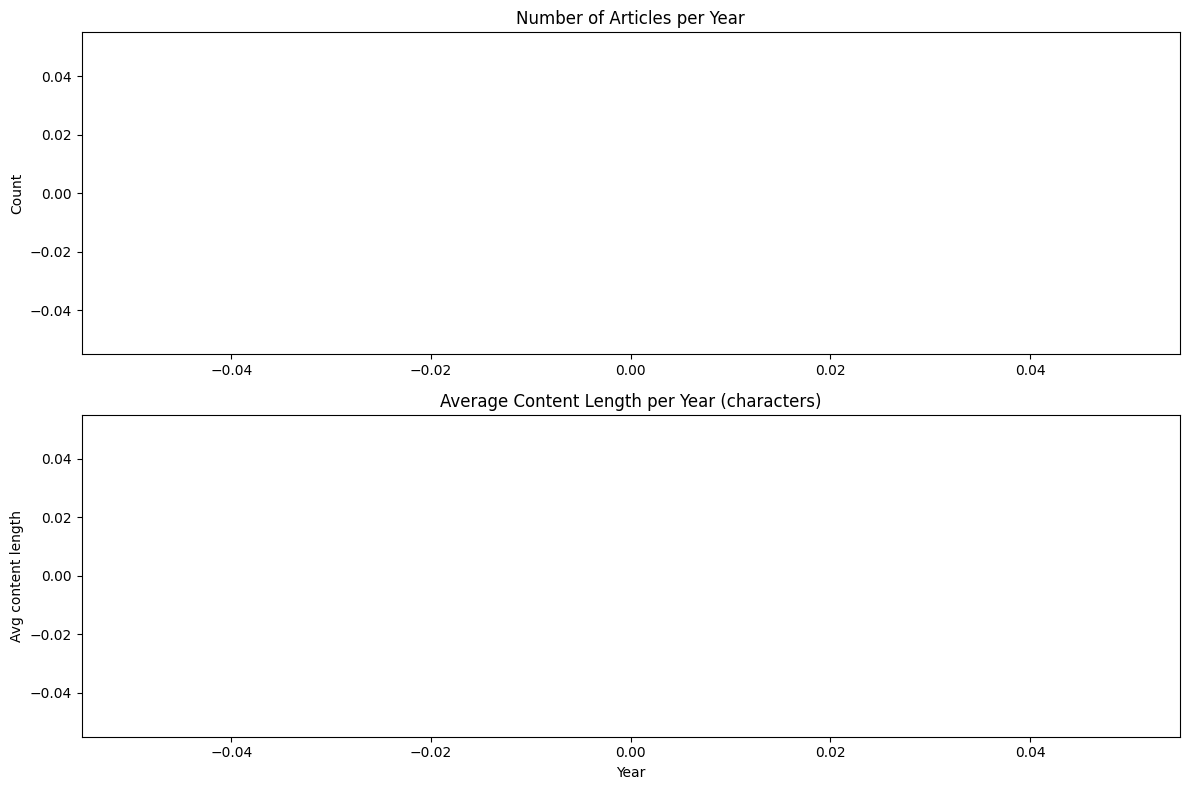

In [21]:
# Cell 13 - Yearly trends plot
yearly_df = yearly_trends(df)
yearly_df = yearly_df[
    (yearly_df["publish_year"] >= 2010) & (yearly_df["publish_year"] <= 2025)
]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(yearly_df["publish_year"], yearly_df["article_count"],
             color="#2E75B6", linewidth=2)
axes[0].set_title("Number of Articles per Year")
axes[0].set_ylabel("Count")

axes[1].plot(yearly_df["publish_year"], yearly_df["avg_content_length"],
             color="#70AD47", linewidth=2)
axes[1].set_title("Average Content Length per Year (characters)")
axes[1].set_ylabel("Avg content length")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.savefig("../data/processed/analytics/yearly_trends.png", dpi=120)
plt.show()

In [22]:
# Cell 14 - Save yearly trends
yearly_df.to_csv("../data/processed/analytics/yearly_trends.csv", index=False)

In [23]:
# Cell 15 - Top N articles per source by content length
top_articles = top_n_per_group(
    df, group_col="source_name", sort_col="content_length", n=3
).reset_index(drop=True)

print("Top 3 articles per source by content length:")
print(top_articles[["title", "source_name", "content_length"]].head(9).to_string(index=False))

2026-05-06 12:17:47,931 | src.analytics.aggregator | top_n_per_group: group=source_name sort=content_length n=3 -> 149 rows


Top 3 articles per source by content length:
                                                                                   title   source_name  content_length
                    ۱۰ دانستنی شگفت‌انگیز درباره داروسازان مشهور که تاریخ را تغییر دادند  1pezeshk.com             210
                  Daylesford crash inquest hears doctor has concerns for driver's memory ABC News (AU)             214
              Driver says those killed in 'incomprehensible tragedy' are with him always ABC News (AU)             213
   Analysis of GLP-1 drugs suggests people who stopped using regained 60% of weight lost   Abcnews.com             212
                       Morre aos 58 anos Marcelo Pretto, integrante do grupo Barbatuques  Abril.com.br             213
Iniciativa vai ofertar tratamento com caneta contra obesidade em centros do SUS; entenda  Abril.com.br             213
              Por que combinar manga com abacate pode ser uma boa receita para o coração  Abril.com.br             212
   

In [24]:
# Cell 16 - Time series: parse publishedAt
from src.analytics.time_series import (
    parse_published_dates, build_monthly_series, resample_series, rolling_averages
)

df_dated = parse_published_dates(cleaned_df, date_col="publishedAt")

print("Date columns added:")
print(df_dated[["title", "publishedAt", "publish_year", "publish_month",
                "publish_weekday", "publish_quarter"]].head(5))
print(f"Valid dates: {df_dated['publishedAt'].notna().sum()}")
print(f"NaT values:  {df_dated['publishedAt'].isna().sum()}")

2026-05-06 12:17:49,905 | src.analytics.time_series | Parsed 297 / 297 dates from "publishedAt"


Date columns added:
                                               title  \
0  Scientists discover diet that tricks the body ...   
1  Nature’s powerhouses: The top 8 healthiest ber...   
2  6 Things You Should Do After 5 P.M. to Support...   
3  "Thema hat sich nicht erledigt": Günther will ...   
4                      Can you reverse dog diabetes?   

                publishedAt  publish_year  publish_month  publish_weekday  \
0 2026-02-27 18:05:43+00:00          2026              2                4   
1 2026-03-12 06:00:00+00:00          2026              3                3   
2 2026-03-13 21:30:00+00:00          2026              3                4   
3 2026-02-23 07:28:11+00:00          2026              2                0   
4 2026-03-13 05:17:32+00:00          2026              3                4   

   publish_quarter  
0                1  
1                1  
2                1  
3                1  
4                1  
Valid dates: 297
NaT values:  0


In [25]:
# Cell 17 - Monthly article count series
monthly_articles = build_monthly_series(df_dated, date_col="publishedAt")
print("Monthly article count series (last 12 months):")
print(monthly_articles.tail(12))

2026-05-06 12:17:52,275 | src.analytics.time_series | Monthly series: 2 periods, total=297


Monthly article count series (last 12 months):
publishedAt
2026-02-28 00:00:00+00:00    137
2026-03-31 00:00:00+00:00    160
Freq: ME, dtype: int64


In [26]:
# Cell 18 - Resample to yearly article count
yearly_articles = resample_series(monthly_articles, freq="YE", agg="sum")
print("\nYearly article count totals:")
print(yearly_articles.tail(10))

2026-05-06 12:17:54,632 | src.analytics.time_series | Resampled to freq=YE agg=sum -> 1 periods



Yearly article count totals:
publishedAt
2026-12-31 00:00:00+00:00    297
Freq: YE-DEC, dtype: int64


2026-05-06 12:17:56,217 | src.analytics.time_series | Rolling average window=3 computed
2026-05-06 12:17:56,220 | src.analytics.time_series | Rolling average window=6 computed
2026-05-06 12:17:56,222 | src.analytics.time_series | Rolling average window=12 computed


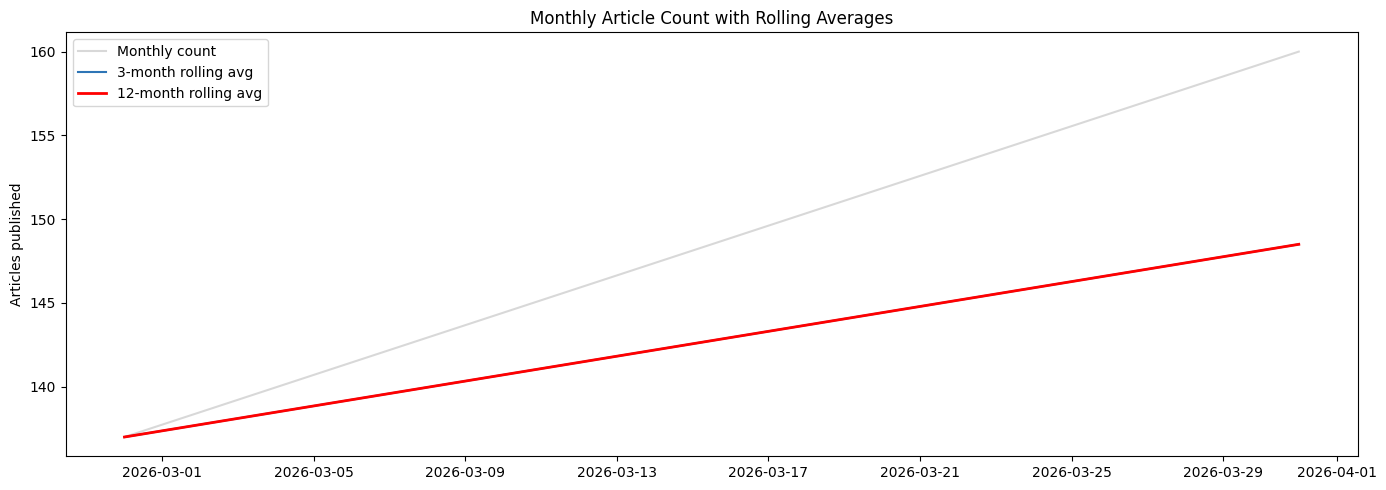

In [27]:
# Cell 19 - Rolling averages on monthly article count
rolling_df = rolling_averages(monthly_articles, windows=(3, 6, 12))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolling_df.index, rolling_df["value"],
        alpha=0.3, color="gray", label="Monthly count")
ax.plot(rolling_df.index, rolling_df["rolling_3"],
        color="#2E75B6", linewidth=1.5, label="3-month rolling avg")
ax.plot(rolling_df.index, rolling_df["rolling_12"],
        color="#FF0000", linewidth=2, label="12-month rolling avg")
ax.set_title("Monthly Article Count with Rolling Averages")
ax.set_ylabel("Articles published")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/analytics/rolling_article_count.png", dpi=120)
plt.show()

In [28]:
# Cell 20 - MongoDB aggregation pipeline
from pymongo import MongoClient
from src.analytics.mongo_pipeline import build_source_pipeline, run_pipeline

client = MongoClient("mongodb://localhost:27017/")
collection = client["articles_pipeline"]["raw_articles"]

pipeline = build_source_pipeline(min_article_count=5, top_n=10)
source_pipeline_df = run_pipeline(collection, pipeline)

print("Top 10 sources by article count (MongoDB pipeline result):")
print(source_pipeline_df.to_string(index=False))

2026-05-06 12:18:00,288 | src.analytics.mongo_pipeline | Built source pipeline: min_article_count=5, top_n=10
2026-05-06 12:18:00,331 | src.analytics.mongo_pipeline | Pipeline returned 0 documents


Top 10 sources by article count (MongoDB pipeline result):
Empty DataFrame
Columns: []
Index: []


In [29]:
# Cell 21 - Answer all four analytical questions
from src.analytics.insight_reporter import run_all_questions

# Use the date-parsed DataFrame with content_length
df_analysis = df_dated.copy()
if "content" in df_analysis.columns and "content_length" not in df_analysis.columns:
    df_analysis["content_length"] = df_analysis["content"].str.len().fillna(0).astype(int)

results = run_all_questions(df_analysis)

2026-05-06 12:18:02,187 | src.analytics.insight_reporter | Q1 top sources by volume: 10 rows
2026-05-06 12:18:02,191 | src.analytics.insight_reporter | Q2 avg content length by source: 10 rows
2026-05-06 12:18:02,195 | src.analytics.insight_reporter | Q3 yearly volume: 1 years
2026-05-06 12:18:02,197 | src.analytics.insight_reporter | Q4 top authors by volume: 10 rows



ANALYTICAL FINDINGS SUMMARY

Q1 - Top Source by Volume: Naturalnews.com (26 articles)
Q2 - Longest Avg Content: WebMD (249.0 chars avg)
Q3 - Peak Publication Year: 2026 (297 articles)
Q4 - Top Author: DIE ZEIT: News - (9 articles, 3.0% of dataset)



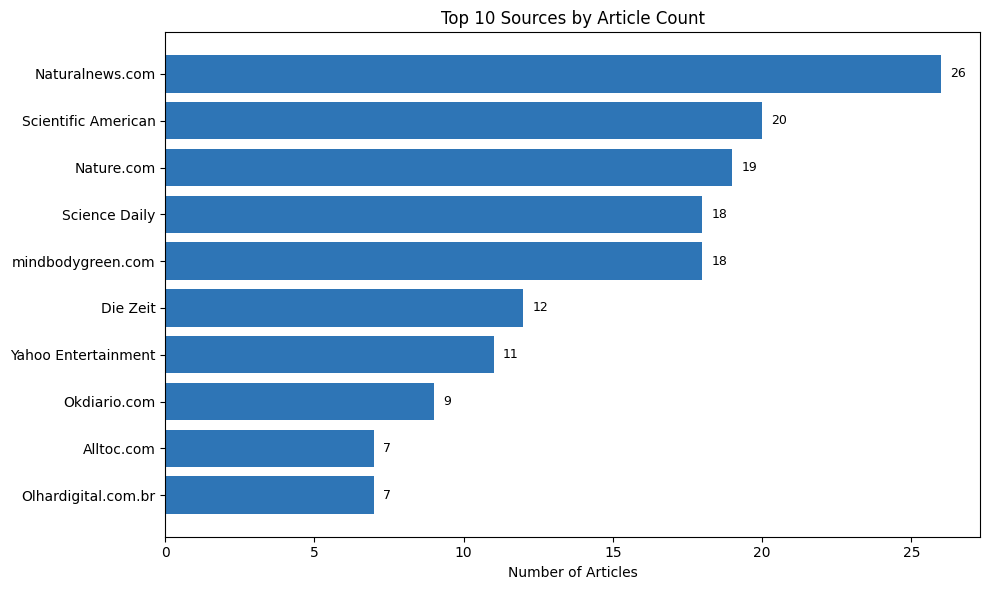

In [30]:
# Cell 22 - Visualise top sources by article count
top_sources_df = results["top_sources"].head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_sources_df["source_name"], top_sources_df["article_count"],
               color="#2E75B6")
ax.set_title("Top 10 Sources by Article Count")
ax.set_xlabel("Number of Articles")
ax.invert_yaxis()

for bar, val in zip(bars, top_sources_df["article_count"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/analytics/top_sources.png", dpi=120)
plt.show()